In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
from scipy.stats import rv_histogram

In [3]:
from urllib.request import urlretrieve

In [ ]:
#urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", "./dr7qso.dat")

In [4]:
z = np.loadtxt("dr7qso.dat", skiprows=80, usecols=3)

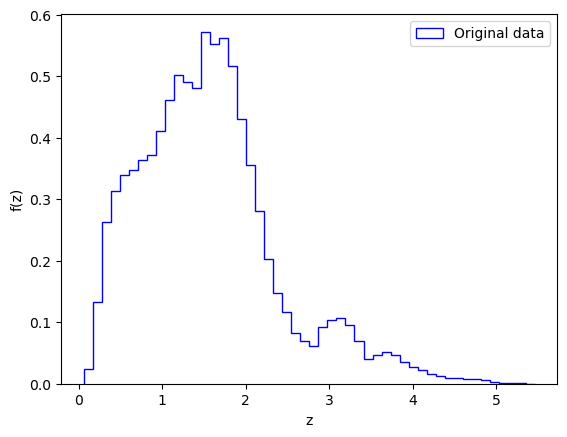

In [5]:
#plt.hist(z)
hist = plt.hist(z,50,density=True,histtype='step',label='Original data',color='b')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.legend();

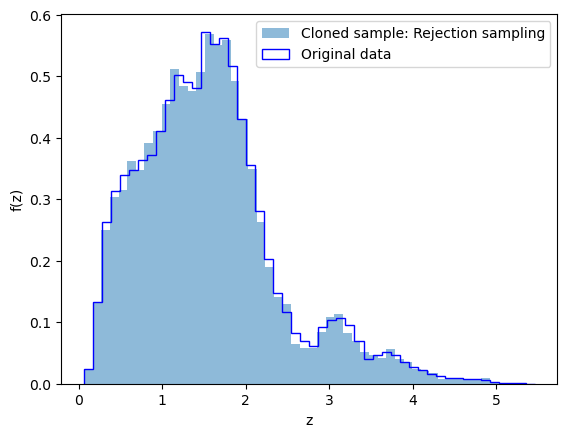

In [6]:
# rejection sampling
N=100000
counts, bins = np.histogram(z,50,density=True)
dist = rv_histogram((counts, bins))


ymax = max(counts)
x = np.random.uniform(0,10,N) #proposed points
y = np.random.uniform(0,ymax,N) #

goodpoints = x[y<=dist.pdf(x)]
plt.hist(goodpoints,50,density=True,alpha=0.5,label='Cloned sample: Rejection sampling')
hist = plt.hist(z,50,density=True,histtype='step',label='Original data', color='b')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.legend();

In [7]:
from scipy.interpolate import interp1d

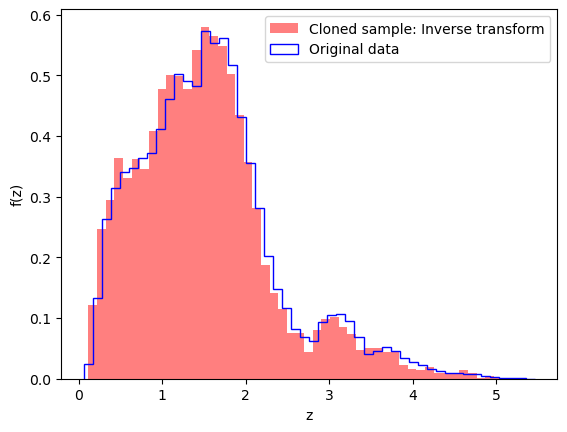

In [8]:
cdf = np.cumsum(counts) / np.sum(counts)
bin_mid = (bins[1:] + bins[:-1]) / 2
cdf_int = interp1d(cdf,bin_mid)

y = np.random.uniform(min(cdf),max(cdf), 10000) 
x_sample = cdf_int(y)

plt.hist(x_sample, bins=50, density=True,label='Cloned sample: Inverse transform',alpha=0.5,color='r');
hist = plt.hist(z,50,density=True,histtype='step',label='Original data', color='b')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.legend();

In [9]:
import astropy
from astropy.cosmology import Planck18

In [10]:
#uniformly distributed in the comoving volume?? No.

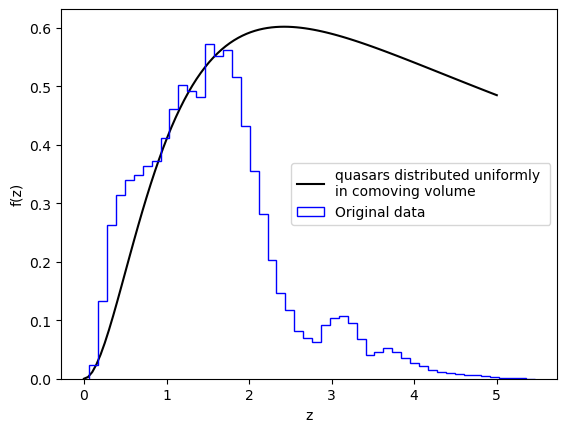

In [20]:
z_vals = np.linspace(0,5,100)
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value
plt.plot(z_vals,comvol/7e10,c='k',label='quasars distributed uniformly \nin comoving volume') ###   Arbitrary normalization, just matching by eye

plt.hist(z,bins=50,histtype='step',density=True,label='Original data',color='b')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.legend();